**BRITISH AIRWAYS - DATA SCIENCE PROJECT**

This first task is focused on scraping and collecting customer feedback, reviewing data from a third-party source(SkyTrax) and analysing this data to present any insights✌️

In [ ]:
import os
os.makedirs("data" , exist_ok=True)
import requests
from bs4 import BeautifulSoup
import pandas as pd
print("Importing and installation successfull if there are no errors")

Importing and installation successfull if there are no errors


In [ ]:
url = "https://www.airlinequality.com/airline-reviews/british-airways/"
headers =  {
    "User-Agent" : "Mozilla/5.0"
}
response = requests.get(url, headers = headers)
soup = BeautifulSoup(response.content, "html.parser")
reviews = soup.find_all("div", class_="text_content")
review_list = [review.get_text(strip=True) for review in reviews]
df = pd.DataFrame(review_list, columns=["Review"])
df.to_csv("data/british_airways_reviews_page1.csv" , index = False)
print(df.head())
print(len(reviews))
print(reviews[0].get_text(strip=True))

                                              Review
0  ✅Trip Verified|   I had an appalling experienc...
1  Not Verified|  Good points, the cabin crew, th...
2  Not Verified|  It was a decent flight, reasona...
3  ✅Trip Verified|   I really like flying British...
4  ✅Trip Verified|   Could not book online the ni...
10
✅Trip Verified|   I had an appalling experience with British Airways. It started when I tried to check in online but couldn’t change my seat due to repeated website errors. I arrived at the airport 4 hours early to sort it out, but the staff at the check-in counter refused to help me—brushing me off before I could even say which flight I was on, simply saying all flights were full. Incredibly rude and unprofessional. The BA lounge was overcrowded, uncomfortable, and poorly equipped—wooden utensils only and very limited seating. Shortly before boarding, I was struck with excruciating abdominal pain. Fearing a medical emergency, I asked to be offloaded. Staff at the boardi

In [ ]:
import csv
with open("british_airways_reviews.csv", mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Review"])
    for review in reviews:
        content = review.get_text(strip=True)
        writer.writerow([content])

In [ ]:
import string
df = pd.read_csv("british_airways_reviews.csv")
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('','',string.punctuation))
    return text

df['Cleaned_Review'] = df['Review'].apply(clean_text)
df.to_csv("british_airways_reviews_cleaned.csv" , index=False)

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df["Cleaned_Review"] = df["Cleaned_Review"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
all_words = " ".join(df["Cleaned_Review"]).split()
word_freq = Counter(all_words)
print(word_freq.most_common(10))

[('verified', 10), ('flight', 10), ('ba', 10), ('boarding', 9), ('✅trip', 8), ('lounge', 7), ('bag', 7), ('cabin', 7), ('staff', 6), ('however', 6)]


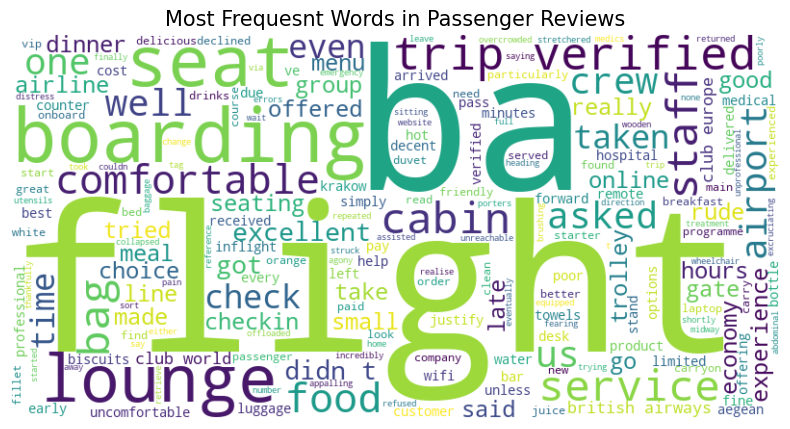

In [ ]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
text = " ".join(df["Cleaned_Review"])
wordcloud = WordCloud(width =  800, height = 400, background_color = 'white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.title("Most Frequesnt Words in Passenger Reviews", fontsize=15)
plt.show()

In [ ]:
!pip install textblob
from textblob import TextBlob
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df["Polarity"] = df["Cleaned_Review"].apply(get_sentiment)
def get_sentiment_label(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Polarity"].apply(get_sentiment_label)
df.to_csv("Sentiment_Analysis.csv", index=False)

Sentiment
Positive    6
Negative    4
Name: count, dtype: int64


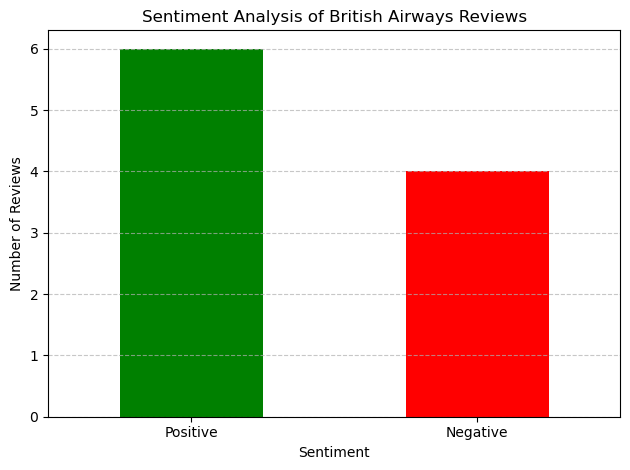

In [ ]:
sentiment_counts = df["Sentiment"].value_counts()
print(sentiment_counts)
sentiment_counts.plot(kind="bar", color=["green", "red", "gray"])
plt.title("Sentiment Analysis of British Airways Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def get_common_words(sentiment):
    filtered = df[df["Sentiment"] == sentiment]
    all_words = " ".join(filtered["Cleaned_Review"]).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(10)

positive_words = get_common_words("Positive")
negative_words = get_common_words("Negative")
neutral_words = get_common_words("Neutral")

print("🔵 Positive:", positive_words)
print("🔴 Negative:", negative_words)
print("⚪ Neutral:", neutral_words)


🔵 Positive: [('flight', 9), ('ba', 9), ('cabin', 7), ('verified', 6), ('food', 6), ('lounge', 6), ('club', 6), ('comfortable', 6), ('crew', 5), ('however', 5)]
🔴 Negative: [('boarding', 6), ('bag', 6), ('asked', 5), ('✅trip', 4), ('verified', 4), ('airport', 4), ('us', 4), ('checkin', 3), ('could', 3), ('rude', 3)]
⚪ Neutral: []
